# 14-LLM Alignment (RLHF & DPO)

In Lesson 13, we used Supervised Fine-Tuning (SFT) to teach a Foundation Model how to talk like a human assistant.

However, SFT suffers from a fatal flaw: **Behavioral Cloning**. SFT treats all training data as equally perfect. If a human labeler writes a response that is helpful but slightly rude, or accurate but overly wordy, SFT mathematically forces the model to mimic that exact rudeness and verbosity. SFT cannot tell the model to "be better" than the humans; it only teaches it to *copy* them.

To achieve superhuman performance, we must mathematically define human values (Helpfulness, Honesty, Harmlessness) and optimize the model to maximize those values. For years, the industry standard was **RLHF (Reinforcement Learning from Human Feedback)**. Today, the absolute bleeding edge is **DPO (Direct Preference Optimization)**.

Let's set up our PyTorch environment to master the mathematics of Alignment.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Alignment (RLHF/DPO) Environment Ready.")

✅ PyTorch Alignment (RLHF/DPO) Environment Ready.


# 1. The Anatomy of RLHF (The 4-Model Nightmare)

To optimize an LLM using Reinforcement Learning, OpenAI (with InstructGPT/ChatGPT) created a brutally complex 3-step pipeline.

### Step 1: The Reward Model (RM)

We cannot put a human inside the training loop to grade 10,000 outputs per second. Instead, we train a second AI to act as the human judge.
We give the SFT model a prompt and have it generate two different responses ($y_{chosen}$ and $y_{rejected}$). A human looks at them and clicks which one is better. We train a **Reward Model ($r_\phi$)** to output a single scalar scalar score for each response, adjusting its weights until $r_\phi(y_{chosen}) > r_\phi(y_{rejected})$.

### Step 2: Proximal Policy Optimization (PPO)

We freeze the Reward Model and let our SFT model (the Actor) generate new answers. The Reward Model grades the answers, and the Actor uses Reinforcement Learning (PPO) to update its weights to maximize the score.

### The KL-Divergence Penalty

If you tell an AI to maximize a score, it will hack the system. It will figure out that the Reward Model loves the word "Absolutely!", and it will start answering every prompt with *"Absolutely! Absolutely! Absolutely!"* to get an infinite score.
To prevent this, RLHF uses a **KL-Divergence penalty**. We keep a frozen copy of the original SFT model (the Reference Policy, $\pi_{ref}$). During PPO, if the Active Policy ($\pi_\theta$) drifts too far away from the Reference Policy's vocabulary distribution, we mathematically penalize the reward.

### The Engineering Nightmare

To run PPO, you must load **four massive LLMs** into VRAM simultaneously:

1. The Active Actor Model ($\pi_\theta$)
2. The Frozen Reference Model ($\pi_{ref}$)
3. The Frozen Reward Model ($r_\phi$)
4. The Value Model (used by PPO to estimate future rewards)

Running RLHF on a 70B model requires unimaginable computing power and is notoriously mathematically unstable.

# 2. The Mathematical Miracle of DPO

In 2023, researchers from Stanford published a paper that completely eliminated PPO, eliminated the Reward Model, and collapsed the entire RLHF pipeline into a single, elegant Loss Function: **Direct Preference Optimization (DPO)**.

DPO relies on a brilliant mathematical substitution. The researchers proved that you can re-parameterize the Reward Model to express the reward *implicitly* using the LLM's own probability outputs.

Instead of training a separate Reward Model, DPO states that the implicit reward $r(x, y)$ of a response is simply the log-ratio of how likely the Active Model ($\pi_\theta$) is to generate that response compared to the Frozen Reference Model ($\pi_{ref}$), scaled by a temperature parameter $\beta$:

$$r(x, y) = \beta \log \frac{\pi_\theta(y | x)}{\pi_{ref}(y | x)}$$

### The DPO Loss Function

Because we now have the reward expressed purely in terms of the language model's probabilities, we can train the LLM directly on the human preference data using a standard binary cross-entropy objective:

$$\mathcal{L}_{DPO} = -\mathbb{E}_{(x, y_w, y_l)} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(y_w | x)}{\pi_{ref}(y_w | x)} - \beta \log \frac{\pi_\theta(y_l | x)}{\pi_{ref}(y_l | x)} \right) \right]$$

* $y_w$: The Winning (Chosen) Response.
* $y_l$: The Losing (Rejected) Response.
* $\sigma$: The Sigmoid function.
* $\beta$: Controls the KL-Divergence (how much we punish drifting from the Reference model).

**The Physics of DPO:** The Active Model looks at the Winning response and increases its probability. It looks at the Losing response and decreases its probability. Simultaneously, it anchors itself against the Reference Model to ensure it doesn't destroy its own grammar. **No Reinforcement Learning required.**

# 3. Architecting DPO Mathematics in PyTorch

Let's build the exact mathematical engine powering DPO. We will simulate an Active Policy and a Reference Policy. We will feed them a batch of "Winning" and "Losing" responses, calculate the implicit rewards, and execute gradient descent to watch the policies diverge.

--- 🧠 Initializing DPO Architecture ---
--- ⚔️ Executing Direct Preference Optimization ---
Final DPO Loss: 0.6912
Final Implicit Reward (Chosen):   0.0019
Final Implicit Reward (Rejected): -0.0019


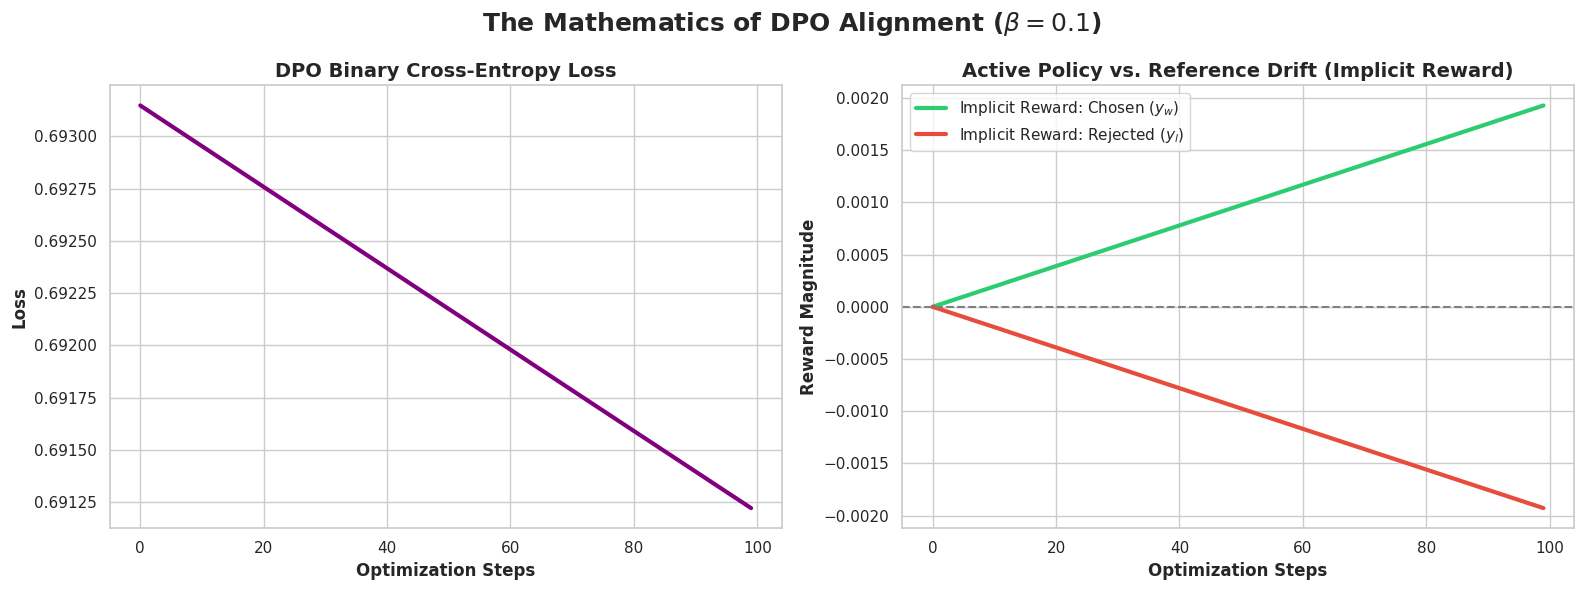


--- 💡 Engineering Insight ---
Look closely at Plot 2. On Step 0, the Implicit Reward for both the Chosen and Rejected responses is exactly 0.0. Why? Because the Active Policy and the Reference Policy are identical ($log(1) = 0$).
As Backpropagation executes, the Active Policy mathematically figures out how to lower the Loss: It violently increases the probability of the Chosen response (driving the Green line up) and decreases the probability of the Rejected response (driving the Red line down).
Because we applied a Beta scaling factor of 0.1, the network is mathematically restrained from pushing the probabilities to infinity, preventing the model from destroying its own grammar!


In [2]:
# 1. DPO Loss Calculus
class DPOLoss(nn.Module):
    def __init__(self, beta=0.1):
        super().__init__()
        self.beta = beta

    def forward(self, policy_chosen_logps, policy_rejected_logps, ref_chosen_logps, ref_rejected_logps):
        """
        Calculates the DPO Loss and Implicit Rewards.
        """
        # Calculate the log ratio for the chosen response: log(pi_theta / pi_ref)
        chosen_logratios = policy_chosen_logps - ref_chosen_logps
        
        # Calculate the log ratio for the rejected response
        rejected_logratios = policy_rejected_logps - ref_rejected_logps
        
        # Calculate the implicit rewards
        chosen_rewards = self.beta * chosen_logratios
        rejected_rewards = self.beta * rejected_logratios
        
        # The DPO Math: Sigmoid of the scaled difference between winning and losing log ratios
        logits = chosen_rewards - rejected_rewards
        loss = -F.logsigmoid(logits).mean()
        
        return loss, chosen_rewards.mean().item(), rejected_rewards.mean().item()

# 2. Simulating the Alignment Environment
print("--- 🧠 Initializing DPO Architecture ---")
BETA = 0.1
dpo_criterion = DPOLoss(beta=BETA)

# We simulate the log probabilities of generating a batch of 128 sequences.
# On Step 1, the Active Policy and Reference Policy are IDENTICAL.
BATCH_SIZE = 128
SEQ_LEN = 50

# The Reference Model is Frozen (No Gradients)
ref_chosen_logps = torch.randn(BATCH_SIZE, requires_grad=False) * 5 - 20
ref_rejected_logps = torch.randn(BATCH_SIZE, requires_grad=False) * 5 - 20

# The Active Policy starts as an exact copy of the Reference Model
policy_chosen_logps = ref_chosen_logps.clone().detach().requires_grad_(True)
policy_rejected_logps = ref_rejected_logps.clone().detach().requires_grad_(True)

# 3. The Optimization Loop
# We use SGD to mathematically adjust the Active Policy's probabilities
optimizer = optim.SGD([policy_chosen_logps, policy_rejected_logps], lr=0.5)

EPOCHS = 100
history_loss = []
history_reward_chosen = []
history_reward_rejected = []

print("--- ⚔️ Executing Direct Preference Optimization ---")
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # Calculate DPO Loss
    loss, r_chosen, r_rejected = dpo_criterion(
        policy_chosen_logps, policy_rejected_logps, 
        ref_chosen_logps, ref_rejected_logps
    )
    
    # Backpropagate to shift the policy probabilities
    loss.backward()
    optimizer.step()
    
    # Track metrics
    history_loss.append(loss.item())
    history_reward_chosen.append(r_chosen)
    history_reward_rejected.append(r_rejected)

print(f"Final DPO Loss: {loss.item():.4f}")
print(f"Final Implicit Reward (Chosen):   {r_chosen:.4f}")
print(f"Final Implicit Reward (Rejected): {r_rejected:.4f}")

# 4. Visualizing the Alignment Calculus
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"The Mathematics of DPO Alignment ($\\beta = {BETA}$)", fontsize=18, fontweight='bold')

# Plot A: The DPO Loss Curve
axes[0].plot(range(EPOCHS), history_loss, color='purple', linewidth=3)
axes[0].set_title("DPO Binary Cross-Entropy Loss", fontweight='bold', fontsize=14)
axes[0].set_xlabel("Optimization Steps", fontweight='bold')
axes[0].set_ylabel("Loss", fontweight='bold')
axes[0].grid(True)

# Plot B: The Implicit Reward Divergence
axes[1].plot(range(EPOCHS), history_reward_chosen, color='#2ecc71', linewidth=3, label="Implicit Reward: Chosen ($y_w$)")
axes[1].plot(range(EPOCHS), history_reward_rejected, color='#e74c3c', linewidth=3, label="Implicit Reward: Rejected ($y_l$)")
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title("Active Policy vs. Reference Drift (Implicit Reward)", fontweight='bold', fontsize=14)
axes[1].set_xlabel("Optimization Steps", fontweight='bold')
axes[1].set_ylabel("Reward Magnitude", fontweight='bold')
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look closely at Plot 2. On Step 0, the Implicit Reward for both the Chosen and Rejected responses is exactly 0.0. Why? Because the Active Policy and the Reference Policy are identical ($log(1) = 0$).")
print("As Backpropagation executes, the Active Policy mathematically figures out how to lower the Loss: It violently increases the probability of the Chosen response (driving the Green line up) and decreases the probability of the Rejected response (driving the Red line down).")
print(f"Because we applied a Beta scaling factor of {BETA}, the network is mathematically restrained from pushing the probabilities to infinity, preventing the model from destroying its own grammar!")

## Real-World Use Case or Analogy:

Think of the transition from RLHF to DPO like **Training a master chef**:

* **RLHF (The Bureaucratic Nightmare)**:
1. The Chef (Active Policy) makes two dishes: a great steak and a burnt steak.
2. Instead of tasting it yourself, you hire a Food Critic (The Reward Model). You spend 6 months training the Food Critic to know what you like.
3. The Chef cooks. The Critic scores the food. The Chef tries to maximize the Critic's score.
4. Eventually, the Chef realizes the Critic gives bonus points for salt, so the Chef dumps a pound of salt on the burnt steak. You have to hire a third person (The KL-Penalty / Reference Model) to stand in the kitchen and slap the Chef's hand if they use too much salt. It is exhausting, unstable, and expensive.


* **DPO (The Direct Feedback Loop)**: You fire the Food Critic. You put the Chef and the Supervisor (The Reference Model) in the kitchen. When the Chef makes the great steak and the burnt steak, you look directly at the Chef and say: *"Cook this one more often. Cook that one less often."* (Direct Preference Optimization). The Supervisor ensures the Chef doesn't change their fundamental cooking style too quickly. It is elegant, mathematically stable, and mathematically guaranteed to reach the exact same optimal policy as RLHF.